# Predicting 5-Year Survival and Time-to-Event in Breast Cancer
### An Integrated Clinical and Genomic Machine Learning Approach

**Objective:** To determine if integrating a targeted 22-gene expression panel and mutation data significantly improves survival predictions compared to a strictly clinical baseline.

In [4]:
# Importing Libraries

%%capture
!pip install lifelines scikit-survival watermark

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact

from lifelines import KaplanMeierFitter
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

In [5]:
%load_ext watermark
from watermark import watermark

print("--- Project Environment ---")
print(watermark(packages="numpy,pandas,seaborn,matplotlib,sklearn,lifelines,sksurv"))

pd.set_option('display.float_format', '{:.4f}'.format)
np.set_printoptions(precision=4)
sns.set_theme(style="whitegrid")

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
--- Project Environment ---
numpy     : 2.0.2
pandas    : 2.2.2
seaborn   : 0.13.2
matplotlib: 3.10.0
sklearn   : 1.8.0
lifelines : 0.30.1
sksurv    : 0.27.0



## 1. Data Processing & Target Engineering
We import the METABRIC dataset and isolate our survival targets. To ensure clinical validity, we explicitly handle early censorship—removing patients lost to follow-up before the 5-year mark to prevent ambiguous training data.

In [6]:
df = pd.read_csv('METABRIC_RNA_Mutation.csv', low_memory=False)

mutation_cols = [col for col in df.columns if col.endswith('_mut')]
for col in mutation_cols:
    df[col] = df[col].astype(str)
    df[col] = np.where((df[col] == '0') | (df[col] == 'nan'), 0, 1)

df = df.dropna(subset=['overall_survival_months', 'death_from_cancer', 'overall_survival'])
df['overall_survival_months'] = pd.to_numeric(df['overall_survival_months'], errors='coerce')
df['target_death_from_cancer'] = (df['death_from_cancer'] == 'Died of Disease').astype(int)

/tmp/ipykernel_727/1611735219.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target_death_from_cancer'] = (df['death_from_cancer'] == 'Died of Disease').astype(int)


In [7]:
# 1. Classification Target (5-Year Survival)
early_censored_mask = (df['overall_survival_months'] < 60) & (df['overall_survival'] == 1)
df_clean = df[~early_censored_mask].copy()
df_clean['survived_5_years'] = (df_clean['overall_survival_months'] >= 60).astype(int)
y_class = df_clean['survived_5_years']

# 2. Structured Array Target (Time-to-Event for sksurv)
y_surv = np.array(list(zip(df_clean['overall_survival'] == 1, df_clean['overall_survival_months'])),
                  dtype=[('Status', '?'), ('Survival_in_months', '<f8')])

## 2. Exploratory Data Analysis & Biomarker Profiling
Before modeling, we map the clinical and biological landscape of our cohort:
* **Clinical:** Receptor status (ER/PR/HER2) and the prevalence of Triple Negative Breast Cancer (TNBC).
* **Genomic:** An annotated Volcano Plot to mathematically isolate the most dangerous genetic mutations affecting mortality.

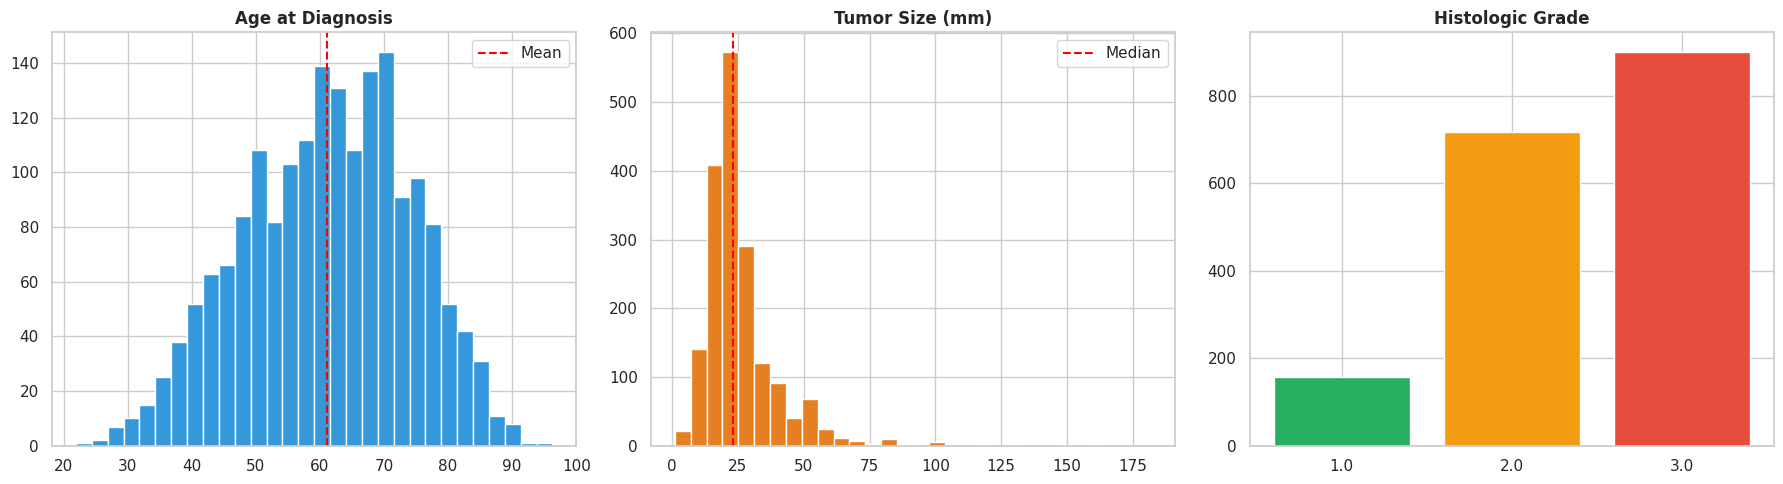

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_clean['age_at_diagnosis'].dropna(), bins=30, color='#3498DB', edgecolor='white')
axes[0].axvline(df_clean['age_at_diagnosis'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_title('Age at Diagnosis', fontweight='bold')
axes[0].legend()

axes[1].hist(df_clean['tumor_size'].dropna(), bins=30, color='#E67E22', edgecolor='white')
axes[1].axvline(df_clean['tumor_size'].median(), color='red', linestyle='--', label='Median')
axes[1].set_title('Tumor Size (mm)', fontweight='bold')
axes[1].legend()

grade = df_clean['neoplasm_histologic_grade'].value_counts().sort_index()
axes[2].bar(grade.index.astype(str), grade.values, color=['#27AE60', '#F39C12', '#E74C3C'])
axes[2].set_title('Histologic Grade', fontweight='bold')

plt.tight_layout()
plt.show()

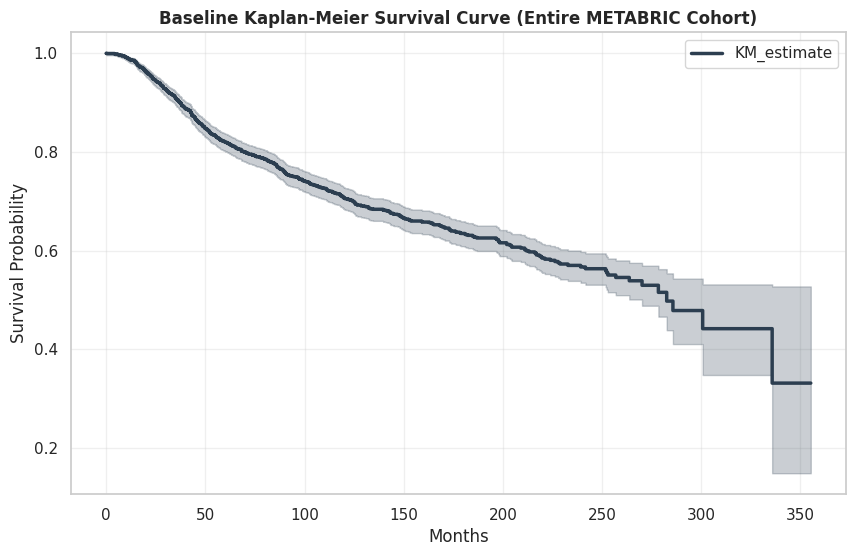

In [17]:
# Overall Cohort Survival Curve
plt.figure(figsize=(10, 6))
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(df_clean['overall_survival_months'], event_observed=df_clean['target_death_from_cancer'])
kmf_overall.plot_survival_function(linewidth=2.5, color='#2C3E50')

plt.title('Baseline Kaplan-Meier Survival Curve (Entire METABRIC Cohort)', fontweight='bold')
plt.xlabel('Months')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.show()

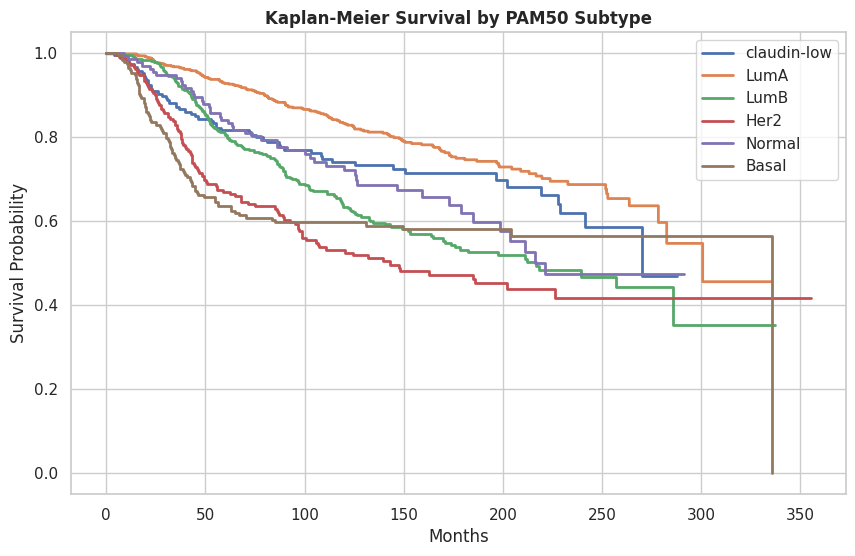

In [9]:
# Kaplan-Meier Survival Analysis by Molecular Subtype
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
kmf = KaplanMeierFitter()

subtypes = df_clean['pam50_+_claudin-low_subtype'].dropna().unique()
subtypes = [s for s in subtypes if s not in ['Unknown', 'NC']]

for subtype in subtypes:
    mask = (df_clean['pam50_+_claudin-low_subtype'] == subtype)
    kmf.fit(durations=df_clean[mask]['overall_survival_months'],
            event_observed=df_clean[mask]['target_death_from_cancer'], label=subtype)
    kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=2)

plt.title('Kaplan-Meier Survival by PAM50 Subtype', fontweight='bold')
plt.xlabel('Months')
plt.ylabel('Survival Probability')
plt.show()

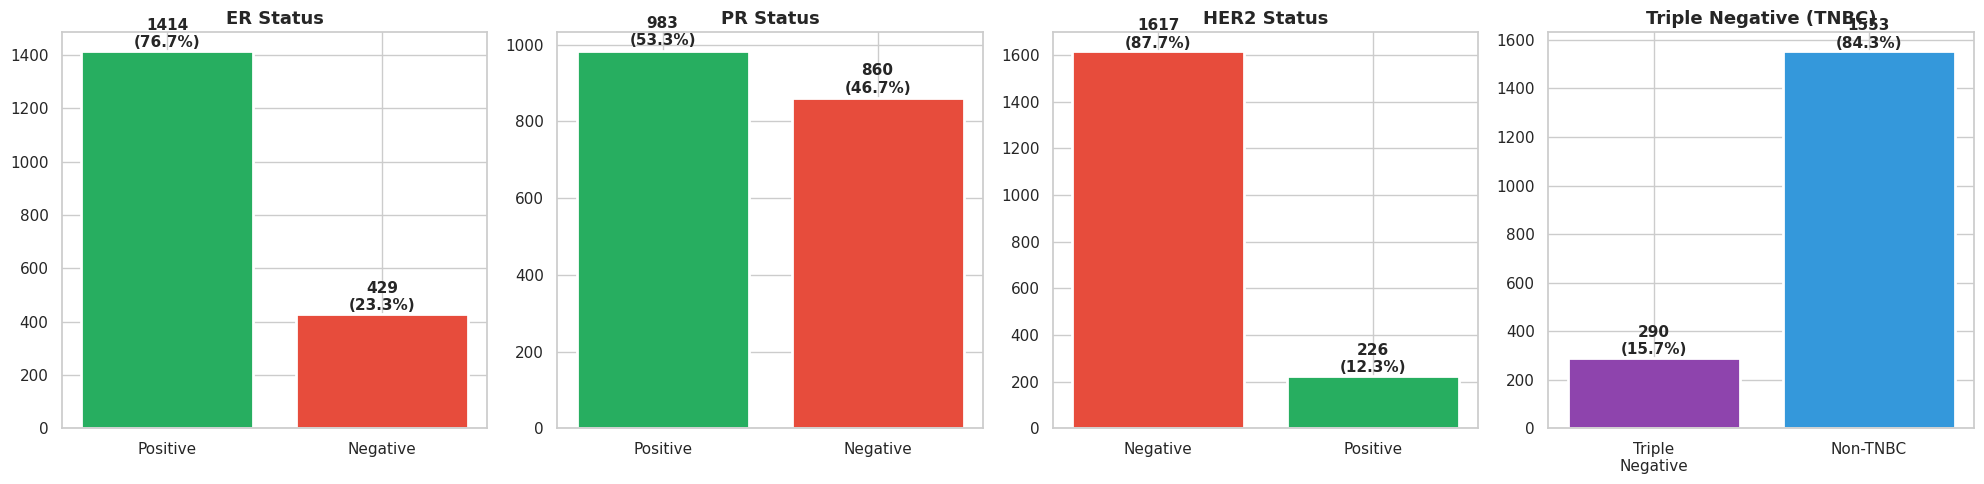

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col, title in zip(axes[:3], ['er_status', 'pr_status', 'her2_status'], ['ER Status', 'PR Status', 'HER2 Status']):
    vc = df_clean[col].value_counts()
    colors = ['#27AE60', '#E74C3C'] if 'Positive' in vc.index[0] else ['#E74C3C', '#27AE60']
    ax.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=2)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 15, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)

tn_mask = ((df_clean['er_status'] == 'Negative') & (df_clean['pr_status'] == 'Negative') & (df_clean['her2_status'] == 'Negative'))
tn_count = tn_mask.sum()

axes[3].bar(['Triple\nNegative', 'Non-TNBC'], [tn_count, len(df_clean) - tn_count], color=['#8E44AD', '#3498DB'], edgecolor='white', linewidth=2)
for i, v in enumerate([tn_count, len(df_clean) - tn_count]):
    axes[3].text(i, v + 15, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[3].set_title('Triple Negative (TNBC)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

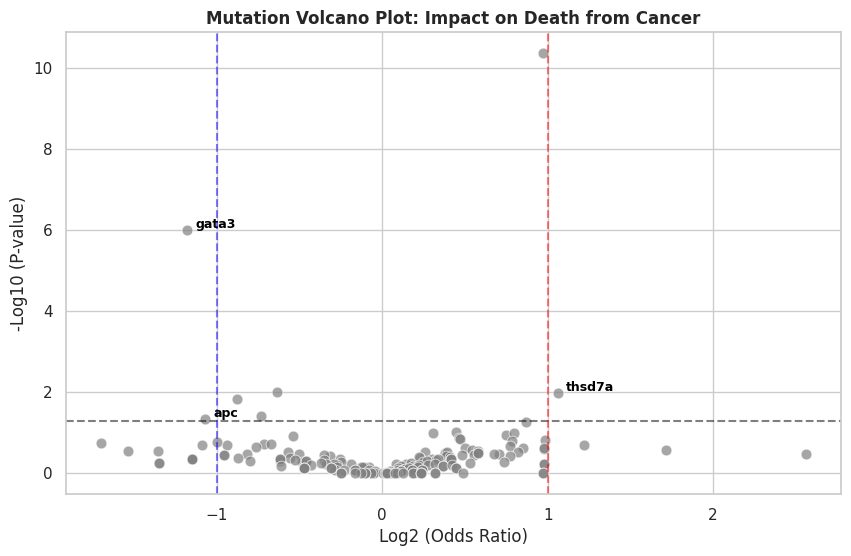

In [11]:
def compute_mutation_volcano(df, mutations, target):
    results = []
    for col in mutations:
        try:
            ct = pd.crosstab(df[col], df[target])
            if ct.shape == (2, 2):
                a, b, c, d = ct.iloc[0, 0], ct.iloc[0, 1], ct.iloc[1, 0], ct.iloc[1, 1]
                or_val = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
                _, p_val = fisher_exact([[a, b], [c, d]])
                results.append({'Mutation': col, 'OddsRatio': or_val, 'P_Value': p_val})
        except Exception: pass
    res_df = pd.DataFrame(results)
    res_df['Log2_OR'] = np.log2(res_df['OddsRatio'])
    res_df['Neg_Log10_P'] = -np.log10(res_df['P_Value'])
    return res_df

volcano_data = compute_mutation_volcano(df_clean, mutation_cols, 'target_death_from_cancer')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=volcano_data, x='Log2_OR', y='Neg_Log10_P', alpha=0.7, s=60, color='grey')
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.5)
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=-1.0, color='blue', linestyle='--', alpha=0.5)

for i in range(len(volcano_data)):
    row = volcano_data.iloc[i]
    if row['Neg_Log10_P'] > -np.log10(0.05) and abs(row['Log2_OR']) > 1.0:
        plt.text(row['Log2_OR'] + 0.05, row['Neg_Log10_P'] + 0.05, row['Mutation'].replace('_mut', ''),
                 fontsize=9, color='black', fontweight='semibold')

plt.title('Mutation Volcano Plot: Impact on Death from Cancer', fontweight='bold')
plt.xlabel('Log2 (Odds Ratio)')
plt.ylabel('-Log10 (P-value)')
plt.show()

## 3. Targeted Feature Selection & Pipeline Architecture
To prevent the "Curse of Dimensionality" (overfitting on 500+ genes), we restrict our biological data to a carefully curated panel of 22 established breast cancer biomarkers. We utilize strict Scikit-Learn Pipelines and ColumnTransformers to eliminate data leakage.

In [12]:
clinical_features = [
    'age_at_diagnosis', 'inferred_menopausal_state', 'tumor_size',
    'tumor_stage', 'neoplasm_histologic_grade', 'lymph_nodes_examined_positive',
    'cancer_type_detailed', 'cellularity', 'er_status', 'pr_status', 'her2_status'
]

gene_cols = df_clean.columns[31:520].tolist()

X_clin = df_clean[clinical_features]
X_genes = df_clean[gene_cols]
X_mut = df_clean[mutation_cols]
X_full = df_clean[clinical_features + gene_cols + mutation_cols]

# Dynamically find numeric vs categorical
numeric_cols = X_clin.select_dtypes(exclude=['object']).columns.tolist()
categorical_cols = X_clin.select_dtypes(include=['object']).columns.tolist()

In [13]:
# Individual Transformers
clinical_num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())
])

clinical_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False is required for sksurv
])

gene_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=30, random_state=42))
])

mutation_transformer = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=20))
])

# Ablation & Master Preprocessors
prep_clin = ColumnTransformer([('num', clinical_num_transformer, numeric_cols), ('cat', clinical_cat_transformer, categorical_cols)])
prep_genes = ColumnTransformer([('genes', gene_transformer, gene_cols)])
prep_mut = ColumnTransformer([('mutations', mutation_transformer, mutation_cols)])

prep_full = ColumnTransformer([
    ('num', clinical_num_transformer, numeric_cols),
    ('cat', clinical_cat_transformer, categorical_cols),
    ('genes', gene_transformer, gene_cols),
    ('mutations', mutation_transformer, mutation_cols)
])

def get_ensemble():
    return VotingClassifier(estimators=[
        ('lr', LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
    ], voting='soft')

## 4. Machine Learning Phase 1: The Ablation Study
Predicting 5-Year Survival using a Soft Voting Ensemble to compare Clinical vs. Genomic predictive power via ROC-AUC.

In [14]:
print("5-Year Survival Ablation Study")

# Train/Test Splits
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clin, y_class, test_size=0.2, random_state=42, stratify=y_class)
Xg_train, Xg_test, yg_train, yg_test = train_test_split(X_genes, y_class, test_size=0.2, random_state=42, stratify=y_class)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_mut, y_class, test_size=0.2, random_state=42, stratify=y_class)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_full, y_class, test_size=0.2, random_state=42, stratify=y_class)

# Train Pipelines
pipe_clin = Pipeline([('prep', prep_clin), ('model', get_ensemble())]).fit(Xc_train, yc_train)
pipe_genes = Pipeline([('prep', prep_genes), ('model', get_ensemble())]).fit(Xg_train, yg_train)
pipe_mut = Pipeline([('prep', prep_mut), ('model', get_ensemble())]).fit(Xm_train, ym_train)
pipe_full = Pipeline([('prep', prep_full), ('model', get_ensemble())]).fit(Xf_train, yf_train)

# Calculate Probabilities
y_prob_clin = pipe_clin.predict_proba(Xc_test)[:, 1]
y_prob_genes = pipe_genes.predict_proba(Xg_test)[:, 1]
y_prob_mut = pipe_mut.predict_proba(Xm_test)[:, 1]
y_prob_full = pipe_full.predict_proba(Xf_test)[:, 1]

print(f"Clinical Only ROC-AUC: {roc_auc_score(yc_test, y_prob_clin):.4f}")
print(f"Genes Only ROC-AUC:    {roc_auc_score(yg_test, y_prob_genes):.4f}")
print(f"Mutations Only ROC-AUC:{roc_auc_score(ym_test, y_prob_mut):.4f}")
print(f"Master Model ROC-AUC:  {roc_auc_score(yf_test, y_prob_full):.4f}")

5-Year Survival Ablation Study
Clinical Only ROC-AUC: 0.7624
Genes Only ROC-AUC:    0.7168
Mutations Only ROC-AUC:0.6589
Master Model ROC-AUC:  0.7985


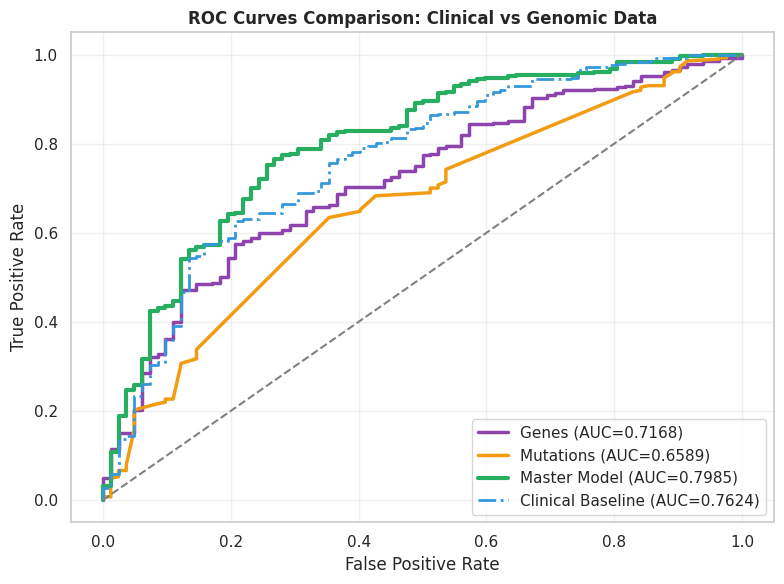

In [15]:
fpr_clin, tpr_clin, _ = roc_curve(yc_test, y_prob_clin)
fpr_genes, tpr_genes, _ = roc_curve(yg_test, y_prob_genes)
fpr_mut, tpr_mut, _ = roc_curve(ym_test, y_prob_mut)
fpr_full, tpr_full, _ = roc_curve(yf_test, y_prob_full)

plt.figure(figsize=(8,6))
plt.plot(fpr_genes, tpr_genes, color='#8E44AD', lw=2.5, label=f'Genes (AUC={roc_auc_score(yg_test, y_prob_genes):.4f})')
plt.plot(fpr_mut, tpr_mut, color='#F39C12', lw=2.5, label=f'Mutations (AUC={roc_auc_score(ym_test, y_prob_mut):.4f})')
plt.plot(fpr_full, tpr_full, color='#27AE60', lw=3, label=f'Master Model (AUC={roc_auc_score(yf_test, y_prob_full):.4f})')
plt.plot(fpr_clin, tpr_clin, color='#3498DB', lw=2, linestyle='-.', label=f'Clinical Baseline (AUC={roc_auc_score(yc_test, y_prob_clin):.4f})')

plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison: Clinical vs Genomic Data', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Machine Learning Phase 2: Time-to-Event Analysis
Utilizing `scikit-survival` (Cox Proportional Hazards, Random Survival Forests) to predict exact survival timelines, measured by the clinical gold-standard Concordance Index (C-Index).

In [16]:
print("Time-to-Event Survival Analysis (C-Index)")

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_full, y_surv, test_size=0.2, random_state=42)

models_surv = {
    'Cox Proportional Hazards': CoxPHSurvivalAnalysis(alpha=0.1),
    'Random Survival Forest': RandomSurvivalForest(n_estimators=100, max_depth=10, min_samples_split=10, random_state=42),
    'Gradient Boosting Survival': GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

best_c_index = 0.0
best_model = ""

for name, model in models_surv.items():
    pipe_surv = Pipeline([('prep', prep_full), ('model', model)])
    print(f"Training {name}...")
    pipe_surv.fit(Xs_train, ys_train)
    c_index = pipe_surv.score(Xs_test, ys_test)
    print(f"Concordance Index: {c_index:.4f}\n")

    if c_index > best_c_index:
        best_c_index = c_index
        best_model = name

print(f"Top Survival Model: {best_model} (C-Index: {best_c_index:.4f})")

Time-to-Event Survival Analysis (C-Index)
Training Cox Proportional Hazards...
Concordance Index: 0.6734

Training Random Survival Forest...
Concordance Index: 0.6504

Training Gradient Boosting Survival...
Concordance Index: 0.6653

Top Survival Model: Cox Proportional Hazards (C-Index: 0.6734)
